In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
def load_and_preprocess_data(file_path):
    """Load dataset, drop irrelevant columns, and preprocess categorical variables."""
    df = pd.read_csv(file_path)
    df.drop(columns=['patientid'], inplace=True)  # Drop non-informative ID column
    
    X = df.drop(columns=['target'])
    y = df['target']
    
    # Standardize numerical features for better performance
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, y, scaler, X.columns.tolist()

In [3]:
def train_decision_tree(X, y):
    """Train a Decision Tree Classifier with optimal hyperparameters."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initialize and train the Decision Tree Classifier
    model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
    model.fit(X_train, y_train)
    
    return model, X_train, X_test, y_train, y_test

In [4]:
def evaluate_model(model, X_test, y_test):
    """Evaluate model performance using accuracy, classification report, and confusion matrix."""
    y_pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [5]:
def visualize_decision_tree(model, feature_names):
    """Visualize the decision tree to understand how it makes decisions."""
    plt.figure(figsize=(20,10))
    plot_tree(model, feature_names=feature_names, class_names=['No Disease', 'Disease'], filled=True, rounded=True)
    plt.show()

In [6]:
def predict_disease(model, scaler, feature_names):
    """Take user input, preprocess it, and predict disease occurrence."""
    print("\nEnter the following details to check for cardiovascular disease:")
    user_input = []
    for feature in feature_names:
        value = float(input(f"Enter {feature}: "))
        user_input.append(value)
    
    user_input_scaled = scaler.transform([user_input])
    prediction = model.predict(user_input_scaled)
    
    print("\nPrediction:", "Disease Present" if prediction[0] == 1 else "No Disease")

Loading and preprocessing data...
Training Decision Tree Classifier...
Evaluating model performance...
Accuracy: 0.945

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94        83
           1       0.97      0.93      0.95       117

    accuracy                           0.94       200
   macro avg       0.94      0.95      0.94       200
weighted avg       0.95      0.94      0.95       200


Confusion Matrix:
 [[ 80   3]
 [  8 109]]
Visualizing the Decision Tree...


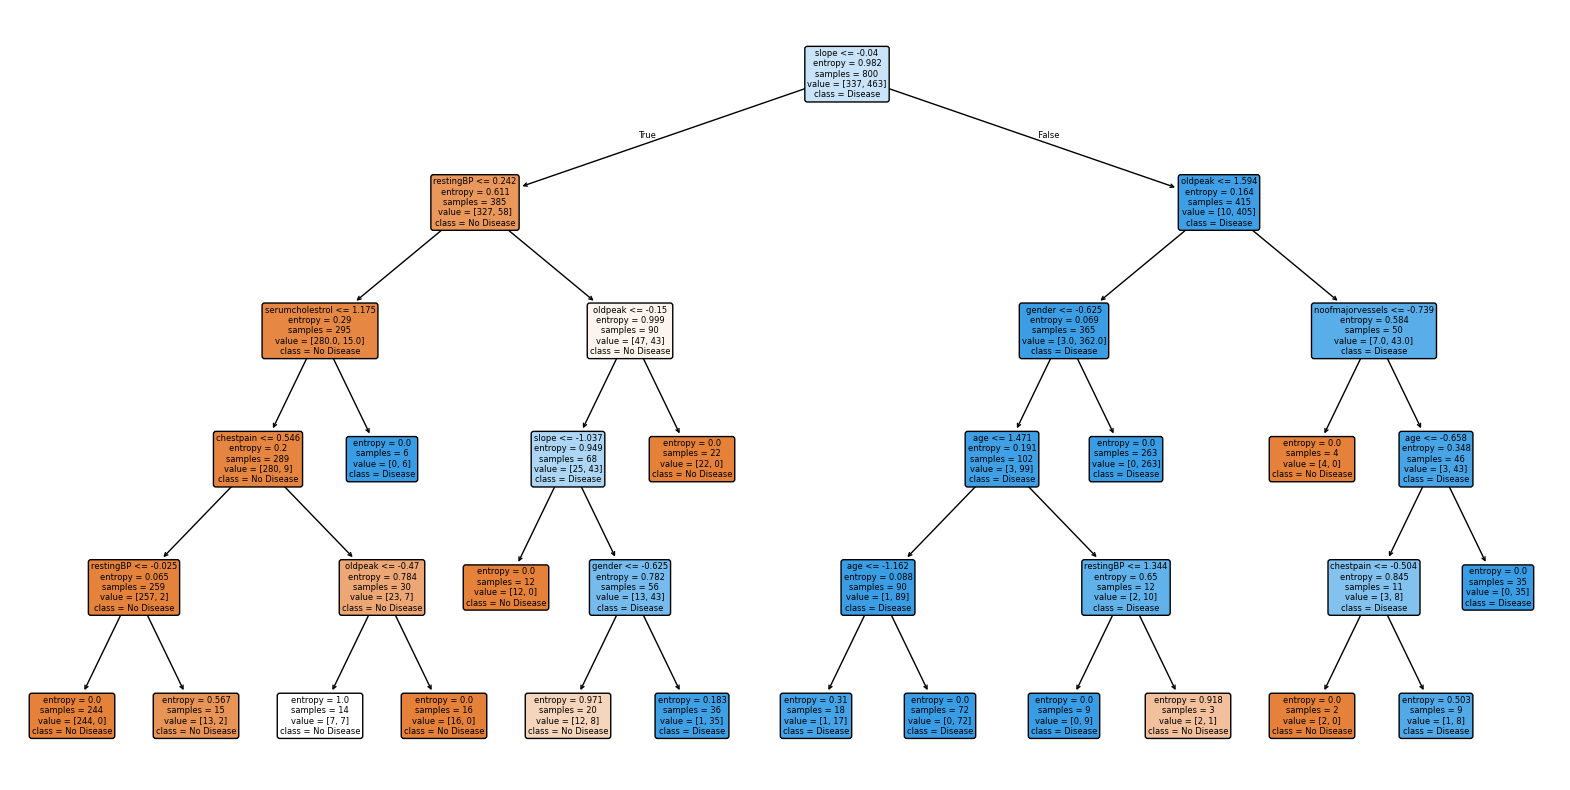


Enter the following details to check for cardiovascular disease:


Enter age:  98
Enter gender:  1
Enter chestpain:  1
Enter restingBP:  160
Enter serumcholestrol:  255
Enter fastingbloodsugar:  2
Enter restingrelectro:  1
Enter maxheartrate:  190
Enter exerciseangia:  0
Enter oldpeak:  4.7
Enter slope:  3
Enter noofmajorvessels:  2



Prediction: Disease Present


C:\Users\KIIT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [7]:
file_path = "Cardiovascular_Disease_Dataset.csv"    
print("Loading and preprocessing data...")
X, y, scaler, feature_names = load_and_preprocess_data(file_path)    
print("Training Decision Tree Classifier...")
model, X_train, X_test, y_train, y_test = train_decision_tree(X, y)    
print("Evaluating model performance...")
evaluate_model(model, X_test, y_test)    
print("Visualizing the Decision Tree...")
visualize_decision_tree(model, feature_names)    
# Predict disease based on user input
predict_disease(model, scaler, feature_names)